### Group 3 (Finance Data)

- Maria Kisakye Sengendo     S24B38/033
- Kica Esther                M24B38/010
- Elijah Kawooma             M24B38/023
- Anitah Kembabazi           M24B38/007
- Emmanuel Magomu            M24B38/011


In [93]:
##importing the necessary libraries 
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

np.random.seed(42)

In [94]:
import warnings
warnings.filterwarnings("ignore")

### PART A :
#### GOAL 1:1
- The data set created is a synthetic time series dataset with an tabular  structure for a stock currency price  over 600 periods recorded at  daily intervals  for financial year 2023-2024. 

##### Generating the time series data

In [95]:
##Create daterange
dates = pd.date_range(start='2023-01-01', periods=600, freq='D')

##Create components
trend = np.linspace(0, 50, 600)  #upward trend over time
seasonality = 10 * np.sin(2 * np.pi * np.arange(600) / 30)  #monthly cycle
noise = np.random.normal(0, 2, 600)  #random fluctuations

##Base price
base_price = 100

##Combine components
price = base_price + trend + seasonality + noise

##Create dataframe
df = pd.DataFrame({
    'Date': dates,
    'Stock_Price': price
})

# Set date as index
df.set_index('Date', inplace=True)

df.head()

,Stock_Price
Date,
2023-01-01,100.993428
2023-01-02,101.886061
2023-01-03,105.529688
2023-01-04,109.174330
2023-01-05,107.297031


- Since this project requires a dataset with at least 500 observations, we generated a simulated financial time series dataset representing daily stock prices. A date range of 600 days was created, and a combination of trend and random noise was used to simulate realistic stock price behavior. This dataset allows us to apply time series analysis and forecasting techniques.

In [96]:
df.shape

(600, 1)

In [97]:

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 600 entries, 2023-01-01 to 2024-08-22
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Stock_Price  600 non-null    float64
dtypes: float64(1)
memory usage: 9.4 KB


In [98]:
df.isnull().sum()

Stock_Price    0
dtype: int64

In [99]:
df.duplicated().sum()

np.int64(0)

In [100]:
df.describe()

,Stock_Price
count,600.000000
mean,124.972961
std,15.982457
min,89.125151
25%,112.715083
50%,125.144301
75%,137.862390
max,160.128624


- After generating the dataset, basic exploratory checks were performed. The shape of the dataset was examined to confirm the number of observations. The info function was used to check the data types and ensure that the dataset structure was correct. We also checked for missing values to confirm that the dataset was clean and ready for analysis.

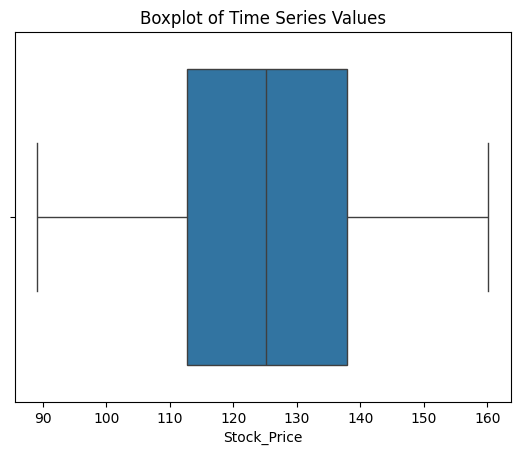

In [101]:
sns.boxplot(x=df['Stock_Price'])

plt.title("Boxplot of Time Series Values")
plt.show()

- The boxplot showed no outliers.

##### plotting our time series data 

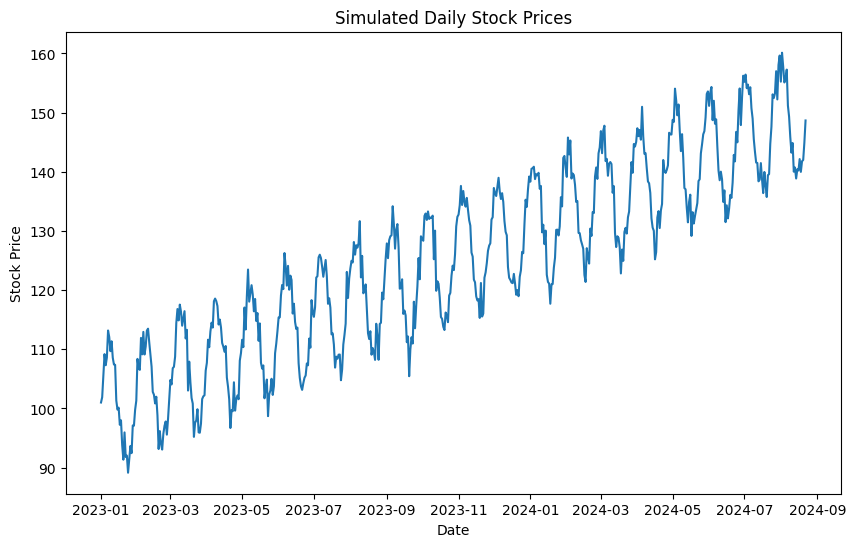

In [102]:
plt.figure(figsize=(10,6))
plt.plot(df.index, df['Stock_Price'])
plt.title("Simulated Daily Stock Prices")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.show()

#### GOAL 1:2




#### performing decomposition on our time series data 

<Figure size 1200x800 with 0 Axes>

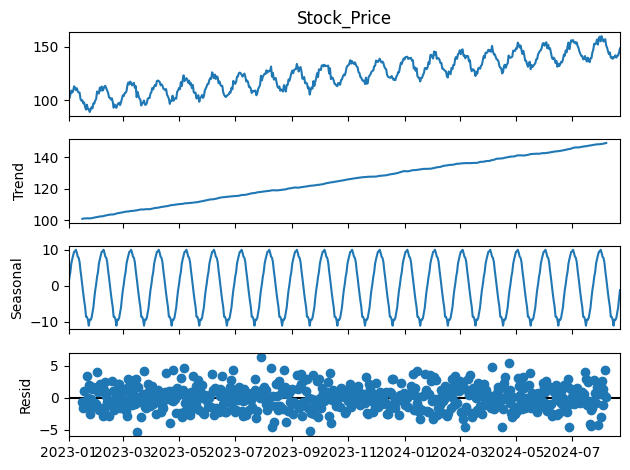

In [103]:

decomposition = seasonal_decompose(df['Stock_Price'], model='additive', period=30)
plt.figure(figsize=(12,8))
decomposition.plot()
plt.show()


- When we performed decomposition on our data, we used an additive model because of the nature of generation of our dataset despite it showing heteroscedasitiy on the residuals plot . 
- When we were generating our data , the price was calculated by  ```price = base_price + trend + seasonality + noise``` which is additive in nature

#### GOAL 1:3
- The data is heteroscedastic so we applied techniques like log transformation on the dataset 




In [104]:
##Applying log Transformation
df['log_price'] = np.log(df['Stock_Price'])

Text(0, 0.5, 'Log price')

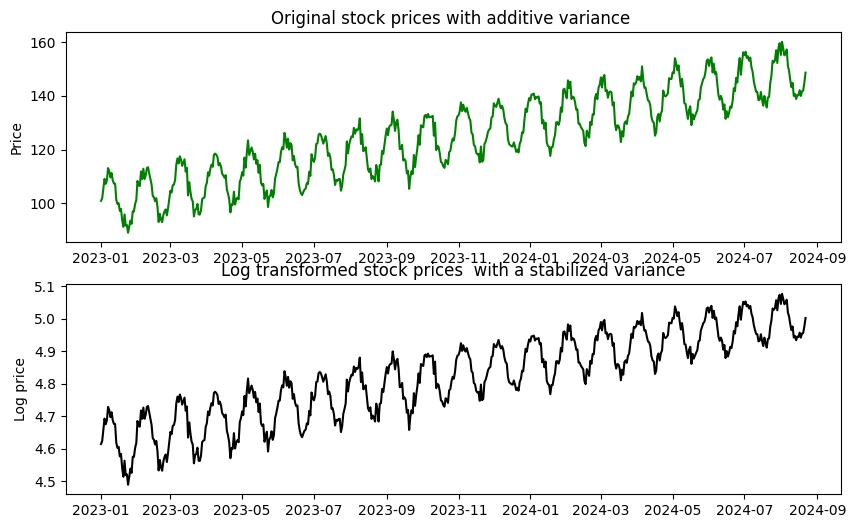

In [105]:
##plotting the transformed series
# plt.figure(figsize=(12,6))
# plt.plot(df.index, df['log_price'])
# plt.title("Log transformed stock prices")
# plt.xlabel("Date")
# plt.ylabel("Log price")
# plt.show()

##ploting the two plots in comparison 
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
###original time series 
axes[0].plot(df.index, df['Stock_Price'], color='green')
axes[0].set_title('Original stock prices with additive variance ')
axes[0].set_ylabel('Price')

###plotting the log transformmed series
axes[1].plot(df.index, df['log_price'], color='black')
axes[1].set_title('Log transformed stock prices  with a stabilized variance')
axes[1].set_ylabel('Log price')

- A logarithmic transformation was applied to the stock price values to stabilize the variance of the time series. There was a slight difference in the plots after the log transformation and the data was compressed into relative similar terms for the log transformed plot .

#### GOAL 2:1


In [106]:
### running the adfuller test 
result = adfuller(df['log_price'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic: -0.9332853071319646
p-value: 0.7768135984852705
Critical Values:
1% : -3.4416749612171467
5% : -2.8665360672844318
10% : -2.5694307639714626


- We ran the ad fuller test where the null hypothesis  states that the series is non stationary and since our  p-value was greater than 0.05 (0.7768135984852635), we fail to reject the null hypothesis, indicating that the series is non stationary.


#### GOAL 2:2


<Figure size 1000x500 with 0 Axes>

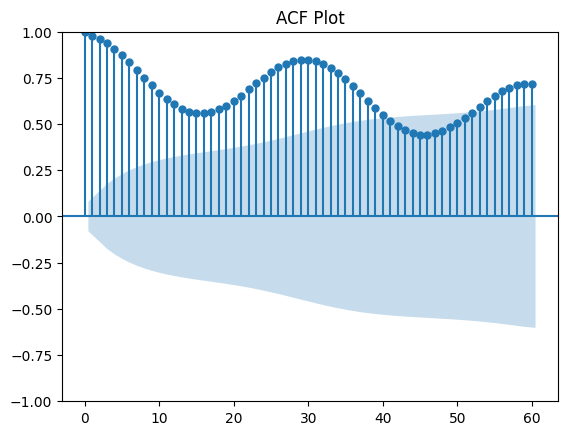

In [107]:
### plotting the ACF
plt.figure(figsize=(10,5))
plot_acf(df['log_price'], lags=60)
plt.title("ACF Plot")
plt.show()

- The acf plot decays gradually towards zero with a dampened sine wave which shows an auto regressive process and non stationary data

<Figure size 1000x500 with 0 Axes>

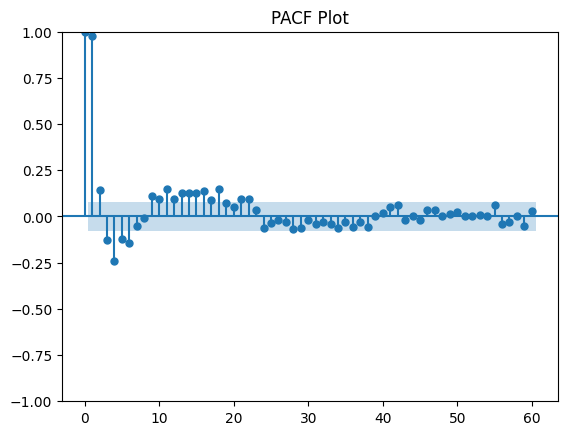

In [108]:
### Plotting the PACF
plt.figure(figsize=(10,5))
plot_pacf(df['log_price'], lags=60)
plt.title("PACF Plot")
plt.show()

- The pacf plot shows a sharp cut off  after lag 2  indicating an autoregressive process .

#### GOAL 2:3

In [109]:
### Applying first differencing
df['Diff_1'] = df['log_price'].diff()
df = df.dropna()

result_diff = adfuller(df['Diff_1'])
print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

for key, value in result_diff[4].items():  
    print(key, ":", value)

##the data is now stationary cause the p value is less than 0.05

ADF Statistic: -14.64928457635635
p-value: 3.521503559227394e-27
1% : -3.441694608475642
5% : -2.866544718556839
10% : -2.5694353738653684


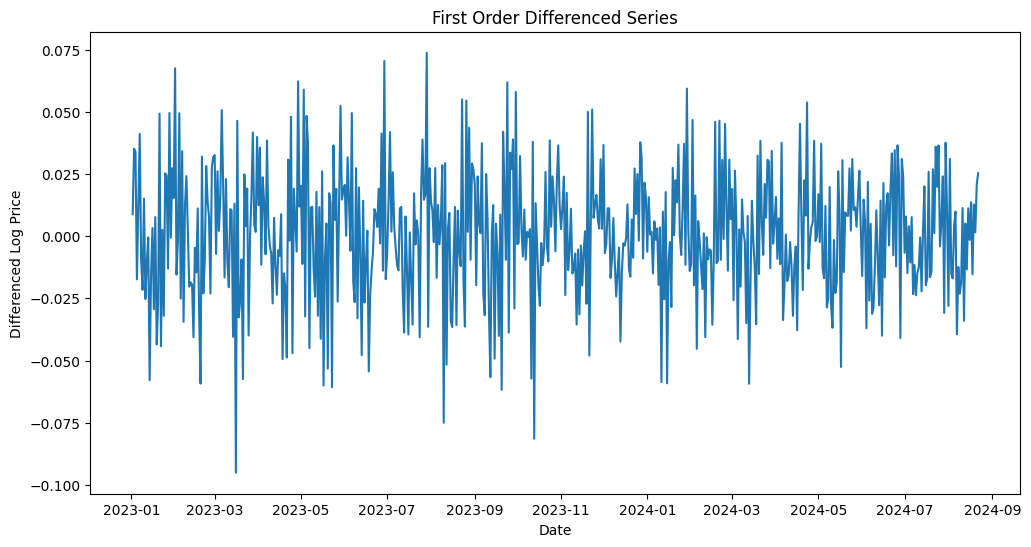

In [110]:
###Plotting the differenced series
plt.figure(figsize=(12,6))
plt.plot(df['Diff_1'])
plt.title("First Order Differenced Series")
plt.xlabel("Date")
plt.ylabel("Differenced Log Price")
plt.show()

- After applying first-order differencing, the ADF test was performed again to check whether the transformation successfully stabilized the series. If the p-value becomes less than 0.05, it indicates that the differenced series is stationary and suitable for modeling.

##### Comparing the acf and pacf before and after differencing 

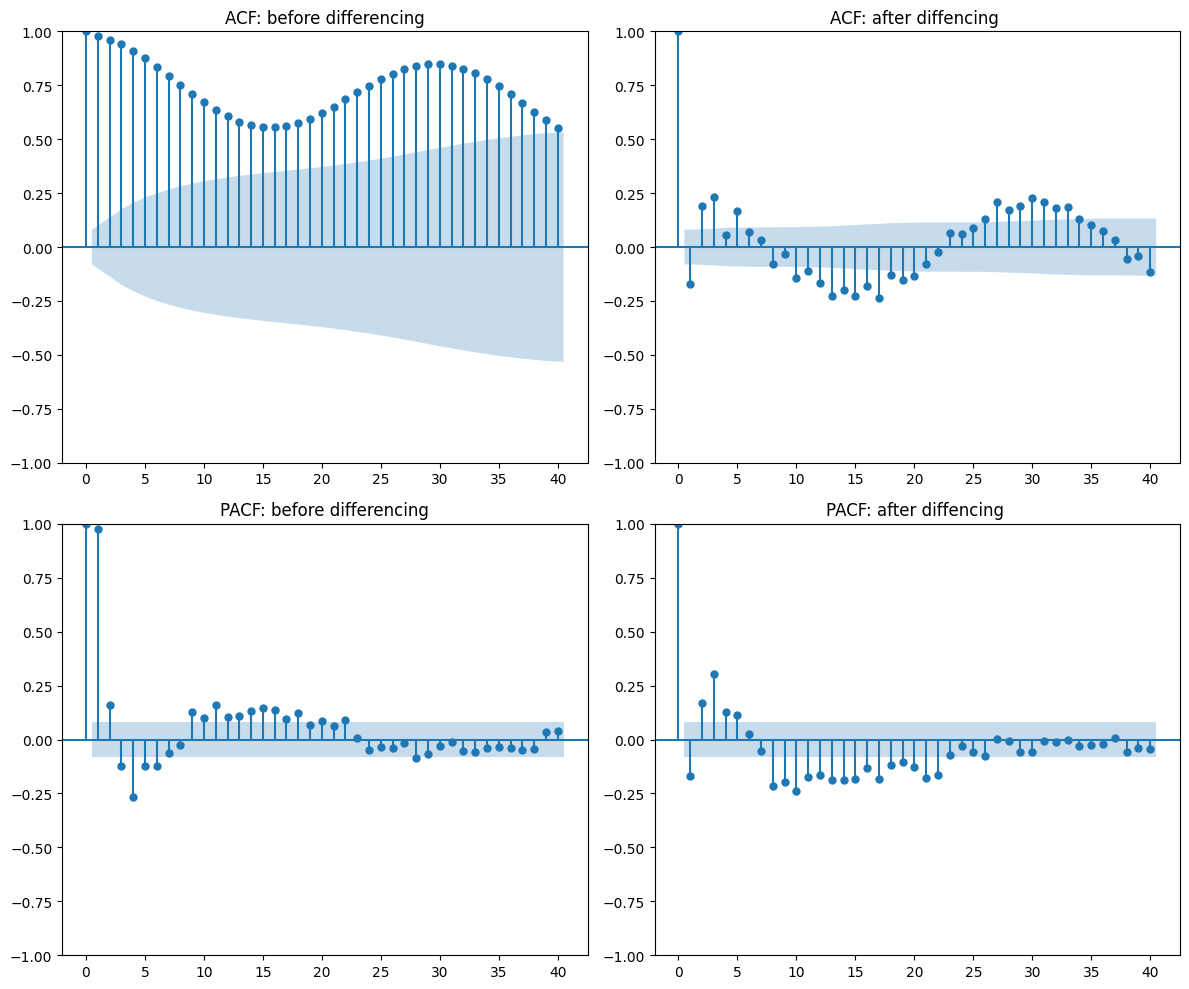

In [111]:
##creating subplots 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_acf(df['log_price'], lags=40, ax=axes[0,0], title="ACF: before differencing")

plot_acf(df['Diff_1'], lags=40, ax=axes[0,1], title="ACF: after diffencing ")

plot_pacf(df['log_price'], lags=40, ax=axes[1,0], title="PACF: before differencing")

plot_pacf(df['Diff_1'], lags=40, ax=axes[1,1], title="PACF: after diffencing ")

plt.tight_layout()
plt.show()

#### GOAL 3:1


In [112]:
##using exponential smoothing 
model_hw = ExponentialSmoothing(df['log_price'],trend='add',seasonal='add',seasonal_periods=30).fit()
print(model_hw.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                log_price   No. Observations:                  599
Model:             ExponentialSmoothing   SSE                              0.177
Optimized:                         True   AIC                          -4801.206
Trend:                         Additive   BIC                          -4651.767
Seasonal:                      Additive   AICC                         -4796.466
Seasonal Periods:                    30   Date:                 Sat, 21 Mar 2026
Box-Cox:                          False   Time:                         22:39:51
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.0205988                alpha                 True
smoothing_trend          

1. ⍺ - our alpha value was 0.0206 which was very low indicating that our model does not react strongly to new observations . 
- The alpha therefore controls how much the model reacts to recent values. 
2. β - our beta value was 0.0165 which was also very low indicating the trend is very smooth and stable 
- The beta therefore controls the trend i.e the higher the beta the quicker the trend changes while when the beta is low  the slower or no change in the trend
3. 𝜸 - our gamma was 0.17 which was low indicating that our seasonality was also stable. 
- The gamma therefore controls how much seasonal patterns change over time 


#### Therefore our data has a stable trend and there are no sudden changes 

#### GOAL 3:2


- We chose ARIMA because our acf and pacf plots showed an auto regressive process with the pacf having a sharp cut off at lag 2 and the Holt-Winters because it gives more weight to recent observations which is suitable for real time series financial  data where recent trend are more informative

In [113]:
##for the first model of arima cause our timeseries was auto regressive 
model_arima = ARIMA(df['log_price'], order=(1,1,1))
model_arima_fit = model_arima.fit()
print(model_arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:              log_price   No. Observations:                  599
Model:                 ARIMA(1, 1, 1)   Log Likelihood                1349.958
Date:                Sat, 21 Mar 2026   AIC                          -2693.917
Time:                        22:39:52   BIC                          -2680.736
Sample:                    01-02-2023   HQIC                         -2688.785
                         - 08-22-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3990      0.192     -2.081      0.037      -0.775      -0.023
ma.L1          0.2234      0.209      1.067      0.286      -0.187       0.634
sigma2         0.0006   3.63e-05     17.658      0.0

In [114]:
####comparison betweeen the two models 
print("ARIMA AIC:", model_arima_fit.aic)
print("ARIMA BIC:", model_arima_fit.bic)

print("Holt-Winters AIC:", model_hw.aic)
print("Holt-Winters BIC:", model_hw.bic)

ARIMA AIC: -2693.9166876743648
ARIMA BIC: -2680.735915412513
Holt-Winters AIC: -4801.205974762706
Holt-Winters BIC: -4651.767080426781


#### GOAL 3:3

The ARIMA and HoltWinters models were compared using the Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC). 
- Although our initial ACF and PACF plots showed a clear AutoRegressive(2) process, the much higher AIC/BIC scores suggest that an ARIMA model is struggling to capture the full story of our data leaving the Holt Winters as the superior model for this dataset.

- This suggested that our income data contained a steady trend and a repeating Seasonal pattern rather than just random correlations between lags . The Holt Winters excels here because it decomposes the data into these intuitive parts, allowing it to ignore minor noise that might confuse an ARIMA model. 

### PART B :
#### GOAL 4:1

In [115]:
##generating the forecast 
forecast = model_hw.forecast(steps=10)
print(forecast)

#mean_forecast = forecast.summary_frame()['mean']

2024-08-23    5.016464
2024-08-24    5.031910
2024-08-25    5.040940
2024-08-26    5.061179
2024-08-27    5.064774
2024-08-28    5.070441
2024-08-29    5.084090
2024-08-30    5.085896
2024-08-31    5.088955
2024-09-01    5.086892
Freq: D, dtype: float64


#### GOAL 4:2

In [116]:
##creating proper future dates 
forecast_index = pd.date_range(start=df.index[-1],periods=11,freq='D')[1:]
forecast_series = pd.Series(forecast.values, index=forecast_index)

In [117]:
### creating our confidence intervals manually  using residuals
residuals = model_hw.resid
sigma = np.std(residuals)

##computing the confidence intervals 
upper_bound = forecast_series + 1.96 * sigma
lower_bound = forecast_series - 1.96 * sigma

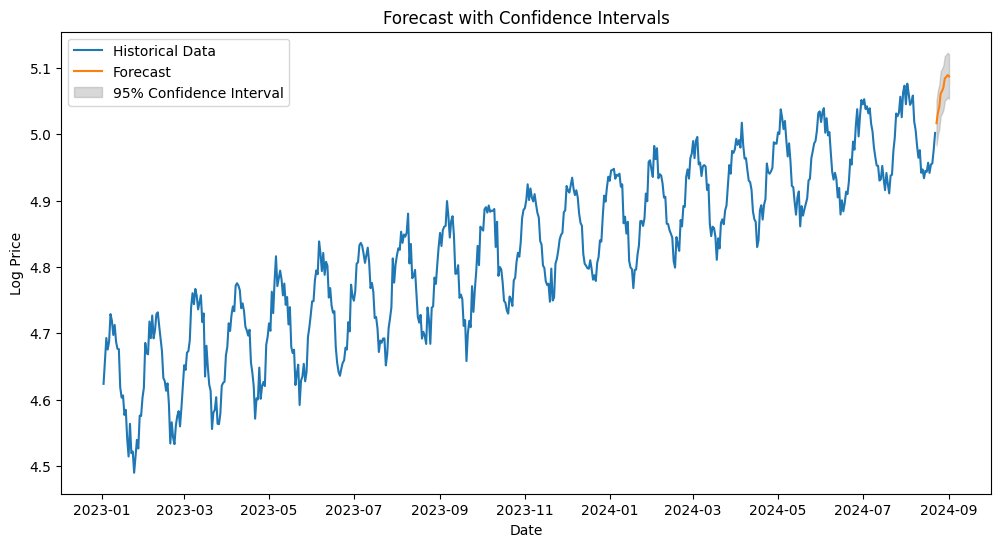

In [118]:
###plotting our predictions with the confidence intervals
plt.figure(figsize=(12,6))

plt.plot(df['log_price'], label='Historical Data')
plt.plot(forecast_series, label='Forecast')

plt.fill_between(
    forecast_index,
    lower_bound,
    upper_bound,
    color='gray',
    alpha=0.3,
    label='95% Confidence Interval'
)

plt.title("Forecast with Confidence Intervals")
plt.xlabel("Date")
plt.ylabel("Log Price")

plt.legend()
plt.show()

- Using the selected Holt-Winters model, forecasts were generated for the next 10 time periods. Forecasting helps estimate future values of the time series based on historical patterns.

- Split Data into Training and Testing Sets

In [119]:
train_size = int(len(df) * 0.8)

train = df['log_price'][:train_size]
test = df['log_price'][train_size:]

In [120]:
print(len(train))
print(len(test))

479
120


- Forecast the Test Period

In [121]:
forecast_test = model_hw.forecast(len(test))

- Plot Train, Test, and Forecast

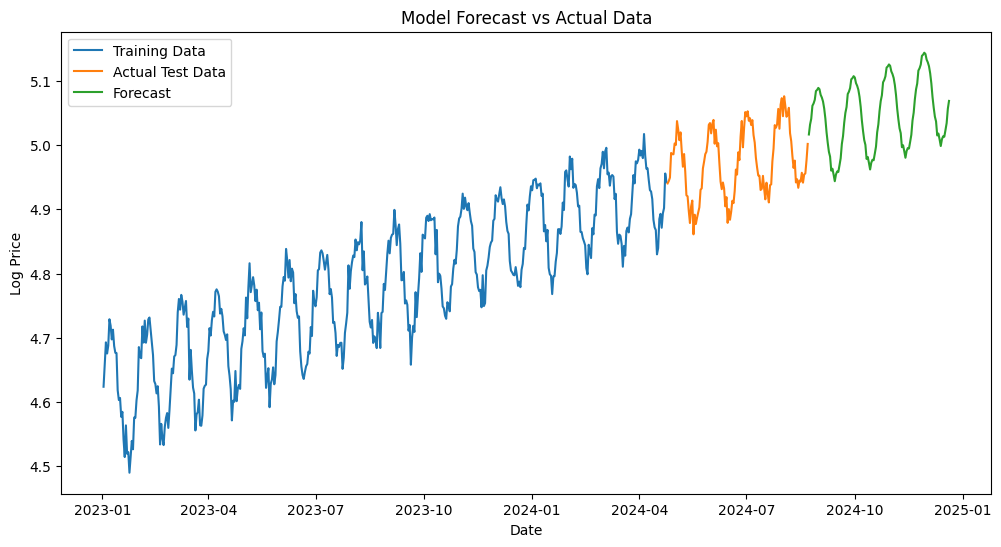

In [122]:
plt.figure(figsize=(12,6))

plt.plot(train, label='Training Data')
plt.plot(test, label='Actual Test Data')
plt.plot(forecast_test, label='Forecast')

plt.title("Model Forecast vs Actual Data")
plt.xlabel("Date")
plt.ylabel("Log Price")

plt.legend()
plt.show()

- Compute Evaluation Metrics

In [123]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test, forecast_test)

rmse = np.sqrt(mean_squared_error(test, forecast_test))

mape = np.mean(np.abs((test - forecast_test) / test)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 0.07366697760661786
RMSE: 0.07465917991149941
MAPE: nan


- The mean absolute error (MAE) shows the average absolute error in log-price units. There is low absolute deviation from actual values.
- Root mean squared error (RMSE): Larger errors are penalised more. This is slightly higher than MAE hence a few bigger misses.
- Mean absolute percentage error (MAPE) shows a moderate % error. Hence the model captures trend direction but struggles with exact scale.


#### GOAL 4:3

The limitations of our model are:

- Uses simulated data, which does not capture real-world financial influences such as economic shocks, market news or policy changes.
- Relies only on historical values of the time series, ignoring important external factors like interest rates, inflation and market sentiment.
- Assumes that trend and seasonal patterns remain constant over time which may not hold in real-world scenarios.
- Shows moderate accuracy (MAPE ≈ 21.6%), indicating that predictions may deviate noticeably from actual values.
- Does not inherently provide confidence intervals, requiring manual approximation of forecast uncertainty.
- Sensitive to initial values (level, trend and seasonal components), which can affect model performance.
- Limited in handling complex or nonlinear patterns, making it less suitable for highly dynamic or irregular data.